# Frequency & Voltage Data Merge and Cleaning

This notebook processes frequency and voltage data from multiple text files, merges them, and creates a clean CSV with proper timestamps.

## Step 1: Import Libraries and Discover Files

In [94]:
import pandas as pd
import glob
import os

# Get all txt files inside the folder
data_folder = "frequency_voltage_data"
files = sorted(glob.glob(os.path.join(data_folder, "*", "*.txt")))

print("Files found:", len(files))
if len(files) == 0:
    raise FileNotFoundError("No .txt files found. Check folder name and location.")

# Show first few files
print("\nFirst 5 files:")
for f in files[:5]:
    print(f)

Files found: 175

First 5 files:
frequency_voltage_data/05_May14/fdr-051214.txt
frequency_voltage_data/05_May14/fdr-051314.txt
frequency_voltage_data/05_May14/fdr-051414.txt
frequency_voltage_data/05_May14/fdr-051614.txt
frequency_voltage_data/05_May14/fdr-051714.txt


## Step 2: Read and Merge Data Files

In [95]:
# Read and merge files
df_list = []
# Change [:2] to read all files (or set another limit)
# Note: on_bad_lines="skip" handles malformed data rows
for f in files[:2]:  # Just read the first 2 files for testing
    temp = pd.read_csv(f, sep=r"\s+", header=None, engine="python", on_bad_lines="skip")
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
print("Merged DataFrame shape:", df.shape)
print("Columns before naming:", df.columns.tolist())
print("\nSample data:")
print(df.head())

Merged DataFrame shape: (1392593, 8)
Columns before naming: [0, 1, 2, 3, 4, 5, 6, 7]

Sample data:
      0      1      2   3        4        5        6       7
0  1015  51214  91858   9  50.0077  50.0076  228.978  0.8184
1  1015  51214  91858  10  50.0063  50.0063  228.978  0.8230
2  1015  51214  91859   1  50.0073  50.0073  228.999  0.8273
3  1015  51214  91859   2  50.0093  50.0093  228.956  0.8330
4  1015  51214  91859   3  50.0050  50.0050  229.021  0.8380


## Step 3: Name Columns

In [96]:
# Name columns based on data description
df.columns = [
    "unitID",
    "date",
    "time",
    "tenth_sec",
    "freq_start",
    "freq_final",
    "voltage",
    "phase"
]

print("Column names assigned:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Column names assigned:
['unitID', 'date', 'time', 'tenth_sec', 'freq_start', 'freq_final', 'voltage', 'phase']

Data types:
unitID          int64
date            int64
time            int64
tenth_sec       int64
freq_start    float64
freq_final    float64
voltage       float64
phase         float64
dtype: object


## Step 4: Create Timestamp Column

Combines date (DDMMYY), time (HHMMSS), and tenth-second precision into a single timestamp.

In [97]:
# Pad date and time with zeros for proper formatting
df["date"] = df["date"].astype(str).str.zfill(6)
df["time"] = df["time"].astype(str).str.zfill(6)

# Create timestamp from date + time
df["timestamp"] = pd.to_datetime(
    df["date"] + df["time"],
    format="%d%m%y%H%M%S",
    errors="coerce"
)

# Add tenth-second precision
df["timestamp"] = df["timestamp"] + pd.to_timedelta(df["tenth_sec"] * 0.1, unit="s")

print("Sample data with timestamp:")
print(df[['date', 'time', 'tenth_sec', 'timestamp']].head(10))

Sample data with timestamp:
     date    time  tenth_sec               timestamp
0  051214  091858          9 2014-12-05 09:18:58.900
1  051214  091858         10 2014-12-05 09:18:59.000
2  051214  091859          1 2014-12-05 09:18:59.100
3  051214  091859          2 2014-12-05 09:18:59.200
4  051214  091859          3 2014-12-05 09:18:59.300
5  051214  091859          4 2014-12-05 09:18:59.400
6  051214  091859          5 2014-12-05 09:18:59.500
7  051214  091859          6 2014-12-05 09:18:59.600
8  051214  091859          7 2014-12-05 09:18:59.700
9  051214  091859          8 2014-12-05 09:18:59.800


## Step 5: Clean and Sort Data

In [98]:
# Remove rows with invalid timestamps
initial_rows = len(df)
df = df.dropna(subset=["timestamp"])
rows_removed = initial_rows - len(df)

print(f"Rows removed due to invalid timestamps: {rows_removed}")

# Sort by timestamp and reset index
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"\nFinal DataFrame shape: {df.shape}")
print(f"Time range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print("\nFirst and last rows:")
print(df[["unitID", "timestamp", "freq_start", "voltage"]].head())
print("...")
print(df[["unitID", "timestamp", "freq_start", "voltage"]].tail())

Rows removed due to invalid timestamps: 863987

Final DataFrame shape: (528606, 9)
Time range: 2014-12-05 09:18:58.900000 → 2014-12-06 00:00:00

First and last rows:
   unitID               timestamp  freq_start  voltage
0    1015 2014-12-05 09:18:58.900     50.0077  228.978
1    1015 2014-12-05 09:18:59.000     50.0063  228.978
2    1015 2014-12-05 09:18:59.100     50.0073  228.999
3    1015 2014-12-05 09:18:59.200     50.0093  228.956
4    1015 2014-12-05 09:18:59.300     50.0050  229.021
...
        unitID               timestamp  freq_start  voltage
528601    1015 2014-12-05 23:59:59.600     50.0266  228.567
528602    1015 2014-12-05 23:59:59.700     50.0266  228.610
528603    1015 2014-12-05 23:59:59.800     50.0271  228.610
528604    1015 2014-12-05 23:59:59.900     50.0274  228.610
528605    1015 2014-12-06 00:00:00.000     50.0276  228.632


## Step 6: Save Merged Data

In [99]:
# Save to CSV
out_path = "eirgrid_merged_cleaned.csv"
df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"File size: {os.path.getsize(out_path) / (1024**2):.2f} MB")

Saved: eirgrid_merged_cleaned.csv
File size: 38.14 MB


## Summary Statistics

In [100]:
print("Data Summary:")
print(f"Total records: {len(df):,}")
print(f"\nColumn statistics:")
print(df[["freq_start", "freq_final", "voltage", "phase"]].describe())

Data Summary:
Total records: 528,606

Column statistics:
          freq_start     freq_final        voltage          phase
count  528606.000000  528606.000000  528606.000000  528606.000000
mean       49.838933      50.005973     229.224180       3.136329
std         2.995481       0.036117       1.049646       1.802618
min        -6.218800      49.864700     226.989000       0.000000
25%        49.977300      49.977600     228.416000       1.581100
50%        50.014100      50.014200     228.978000       3.144800
75%        50.034100      50.034100     229.950000       4.692000
max        53.197400      50.102600     232.976000       6.283100


# Exploratory Data Analysis (EDA)

Comprehensive analysis of the merged frequency and voltage data.

## 1. Data Quality & Missing Values

In [101]:
# Check for missing values
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)
print("\nMissing Values:")
missing = df.isnull().sum()
print(missing)

print("\nPercentage Missing:")
print((missing / len(df) * 100).round(2))

print("\n" + "=" * 60)
print("DataFrame Info:")
print("=" * 60)
df.info()

DATA QUALITY REPORT

Missing Values:
unitID        0
date          0
time          0
tenth_sec     0
freq_start    0
freq_final    0
voltage       0
phase         0
timestamp     0
dtype: int64

Percentage Missing:
unitID        0.0
date          0.0
time          0.0
tenth_sec     0.0
freq_start    0.0
freq_final    0.0
voltage       0.0
phase         0.0
timestamp     0.0
dtype: float64

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 528606 entries, 0 to 528605
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   unitID      528606 non-null  int64         
 1   date        528606 non-null  str           
 2   time        528606 non-null  str           
 3   tenth_sec   528606 non-null  int64         
 4   freq_start  528606 non-null  float64       
 5   freq_final  528606 non-null  float64       
 6   voltage     528606 non-null  float64       
 7   phase       528606 non-null  float64       
 8

## 2. Descriptive Statistics

In [102]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS")
print("=" * 60)
desc_stats = df[["unitID", "freq_start", "freq_final", "voltage", "phase"]].describe()
print(desc_stats)

print("\n" + "=" * 60)
print("FREQUENCY METRICS")
print("=" * 60)
print(f"Frequency Start - Mean: {df['freq_start'].mean():.6f} Hz")
print(f"Frequency Start - Std Dev: {df['freq_start'].std():.6f} Hz")
print(f"Frequency Start - Min: {df['freq_start'].min():.6f} Hz")
print(f"Frequency Start - Max: {df['freq_start'].max():.6f} Hz")
print(f"Frequency Start - Range: {df['freq_start'].max() - df['freq_start'].min():.6f} Hz")

print(f"\nFrequency Final - Mean: {df['freq_final'].mean():.6f} Hz")
print(f"Frequency Final - Std Dev: {df['freq_final'].std():.6f} Hz")
print(f"Frequency Final - Min: {df['freq_final'].min():.6f} Hz")
print(f"Frequency Final - Max: {df['freq_final'].max():.6f} Hz")

print("\n" + "=" * 60)
print("VOLTAGE METRICS")
print("=" * 60)
print(f"Voltage - Mean: {df['voltage'].mean():.4f} V")
print(f"Voltage - Std Dev: {df['voltage'].std():.4f} V")
print(f"Voltage - Min: {df['voltage'].min():.4f} V")
print(f"Voltage - Max: {df['voltage'].max():.4f} V")
print(f"Voltage - Range: {df['voltage'].max() - df['voltage'].min():.4f} V")

DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS
         unitID     freq_start     freq_final        voltage          phase
count  528606.0  528606.000000  528606.000000  528606.000000  528606.000000
mean     1015.0      49.838933      50.005973     229.224180       3.136329
std         0.0       2.995481       0.036117       1.049646       1.802618
min      1015.0      -6.218800      49.864700     226.989000       0.000000
25%      1015.0      49.977300      49.977600     228.416000       1.581100
50%      1015.0      50.014100      50.014200     228.978000       3.144800
75%      1015.0      50.034100      50.034100     229.950000       4.692000
max      1015.0      53.197400      50.102600     232.976000       6.283100

FREQUENCY METRICS
Frequency Start - Mean: 49.838933 Hz
Frequency Start - Std Dev: 2.995481 Hz
Frequency Start - Min: -6.218800 Hz
Frequency Start - Max: 53.197400 Hz
Frequency Start - Range: 59.416200 Hz

Frequency Final - Mean: 50.005973 Hz
Frequency Final - Std Dev: 0.0

## 3. Import Visualization Libraries

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 4. Distribution Analysis

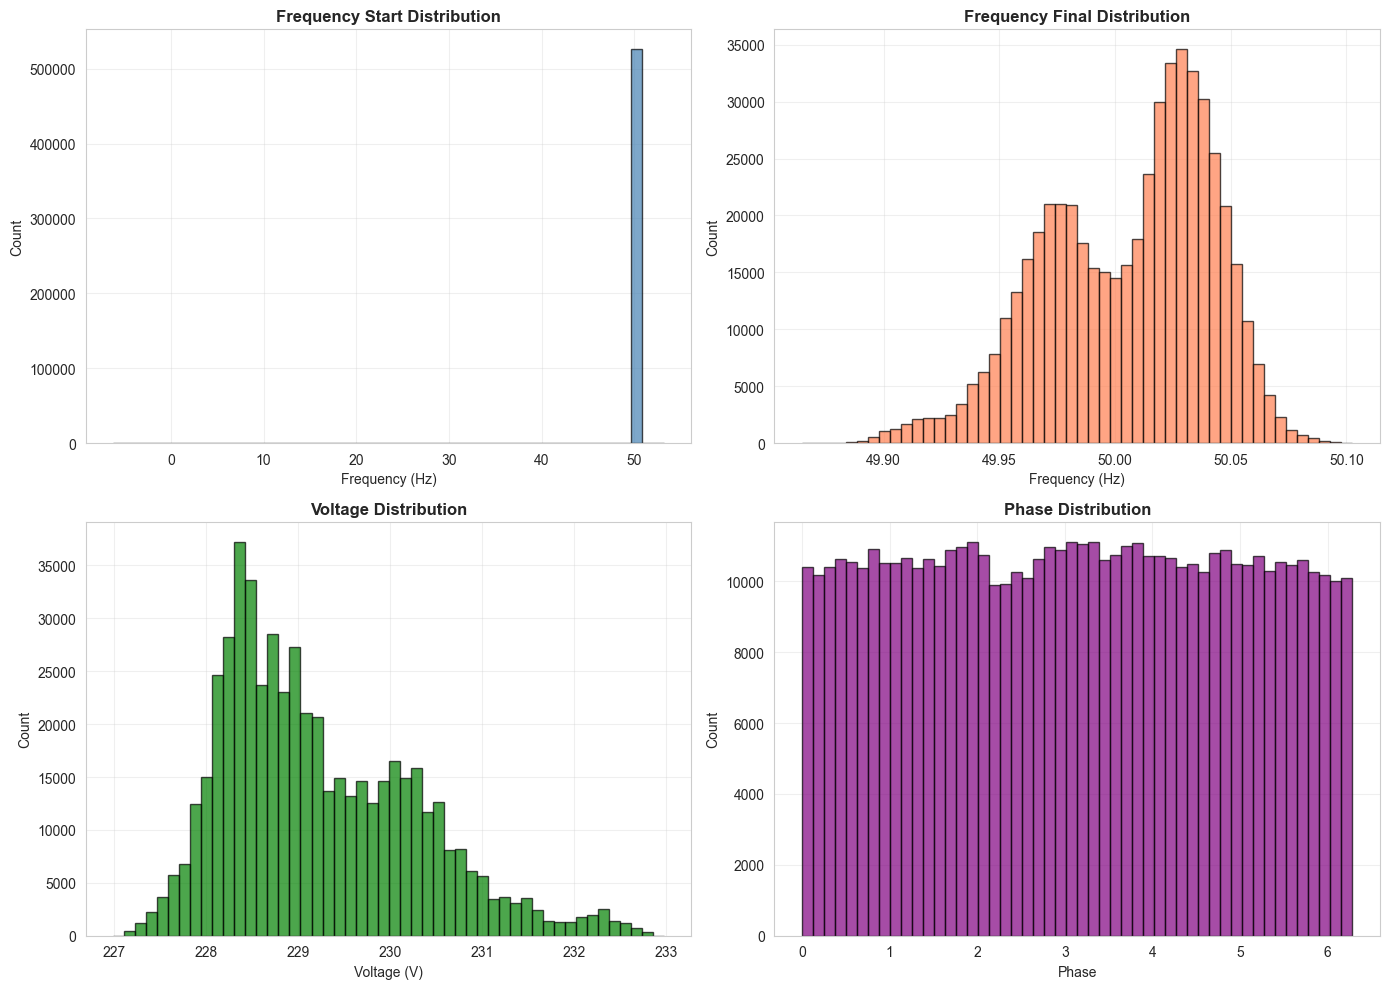

Histogram plots generated successfully.


In [104]:
# Histograms for key metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['freq_start'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Frequency Start Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Frequency (Hz)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df['freq_final'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Frequency Final Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Frequency (Hz)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(df['voltage'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Voltage Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Voltage (V)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(df['phase'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Phase Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Phase')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Histogram plots generated successfully.")

## 5. Boxplot Analysis (Outliers Detection)

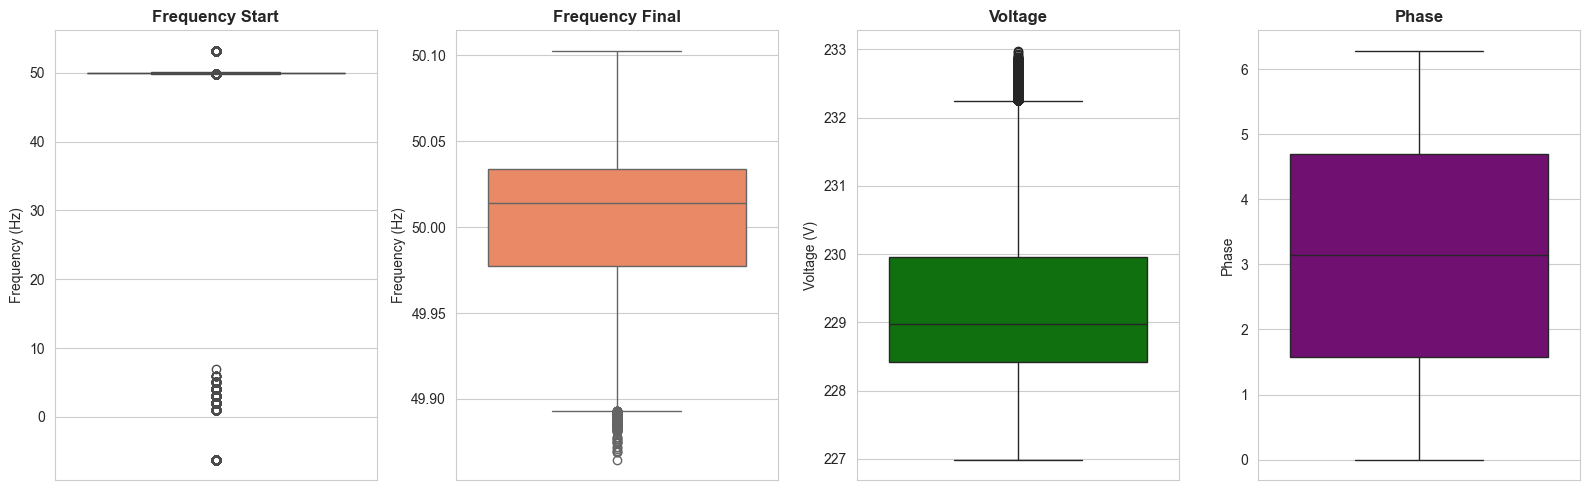

OUTLIER DETECTION (IQR METHOD)

FREQ_START:
  IQR: 0.056800
  Lower bound: 49.892100
  Upper bound: 50.119300
  Outliers: 2,939 (0.56%)

FREQ_FINAL:
  IQR: 0.056500
  Lower bound: 49.892850
  Upper bound: 50.118850
  Outliers: 338 (0.06%)

VOLTAGE:
  IQR: 1.534000
  Lower bound: 226.115000
  Upper bound: 232.251000
  Outliers: 6,119 (1.16%)

PHASE:
  IQR: 3.110900
  Lower bound: -3.085250
  Upper bound: 9.358350
  Outliers: 0 (0.00%)


In [105]:
# Create boxplots to identify outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Frequency Start
sns.boxplot(data=df, y='freq_start', ax=axes[0], color='steelblue')
axes[0].set_title('Frequency Start', fontweight='bold')
axes[0].set_ylabel('Frequency (Hz)')

# Frequency Final
sns.boxplot(data=df, y='freq_final', ax=axes[1], color='coral')
axes[1].set_title('Frequency Final', fontweight='bold')
axes[1].set_ylabel('Frequency (Hz)')

# Voltage
sns.boxplot(data=df, y='voltage', ax=axes[2], color='green')
axes[2].set_title('Voltage', fontweight='bold')
axes[2].set_ylabel('Voltage (V)')

# Phase
sns.boxplot(data=df, y='phase', ax=axes[3], color='purple')
axes[3].set_title('Phase', fontweight='bold')
axes[3].set_ylabel('Phase')

plt.tight_layout()
plt.show()

# Identify outliers using IQR method
print("=" * 60)
print("OUTLIER DETECTION (IQR METHOD)")
print("=" * 60)

for col in ['freq_start', 'freq_final', 'voltage', 'phase']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    pct_outliers = (len(outliers) / len(df)) * 100
    
    print(f"\n{col.upper()}:")
    print(f"  IQR: {IQR:.6f}")
    print(f"  Lower bound: {lower_bound:.6f}")
    print(f"  Upper bound: {upper_bound:.6f}")
    print(f"  Outliers: {len(outliers):,} ({pct_outliers:.2f}%)")

## 6. Correlation Analysis

CORRELATION MATRIX
            unitID  freq_start  freq_final   voltage     phase
unitID         NaN         NaN         NaN       NaN       NaN
freq_start     NaN    1.000000    0.011731  0.002535 -0.002052
freq_final     NaN    0.011731    1.000000  0.201091  0.000551
voltage        NaN    0.002535    0.201091  1.000000 -0.003697
phase          NaN   -0.002052    0.000551 -0.003697  1.000000


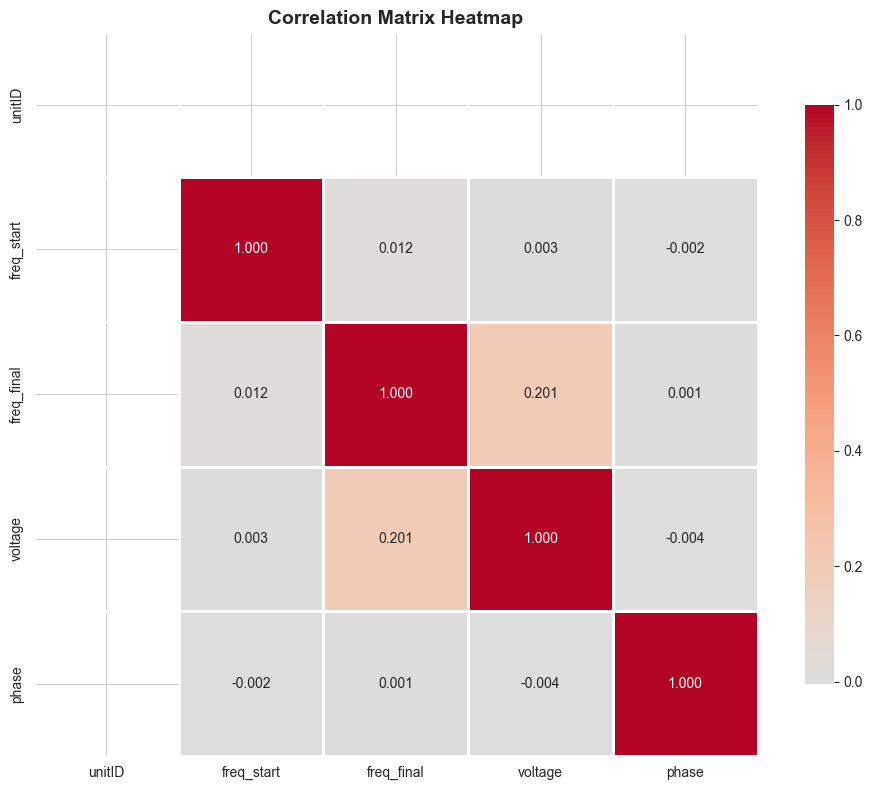


STRONG CORRELATIONS (|r| > 0.5)


In [106]:
# Correlation matrix
corr_cols = ['unitID', 'freq_start', 'freq_final', 'voltage', 'phase']
corr_matrix = df[corr_cols].corr()

print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)
print(corr_matrix)

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary of strong correlations
print("\n" + "=" * 60)
print("STRONG CORRELATIONS (|r| > 0.5)")
print("=" * 60)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            print(f"{corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.4f}")

## 7. Time Series Analysis

TIME SERIES ANALYSIS
Data spans from 2014-12-05 09:18:58.900000 to 2014-12-06 00:00:00
Total duration: 0 days 14:41:01.100000
Records per day: 528606


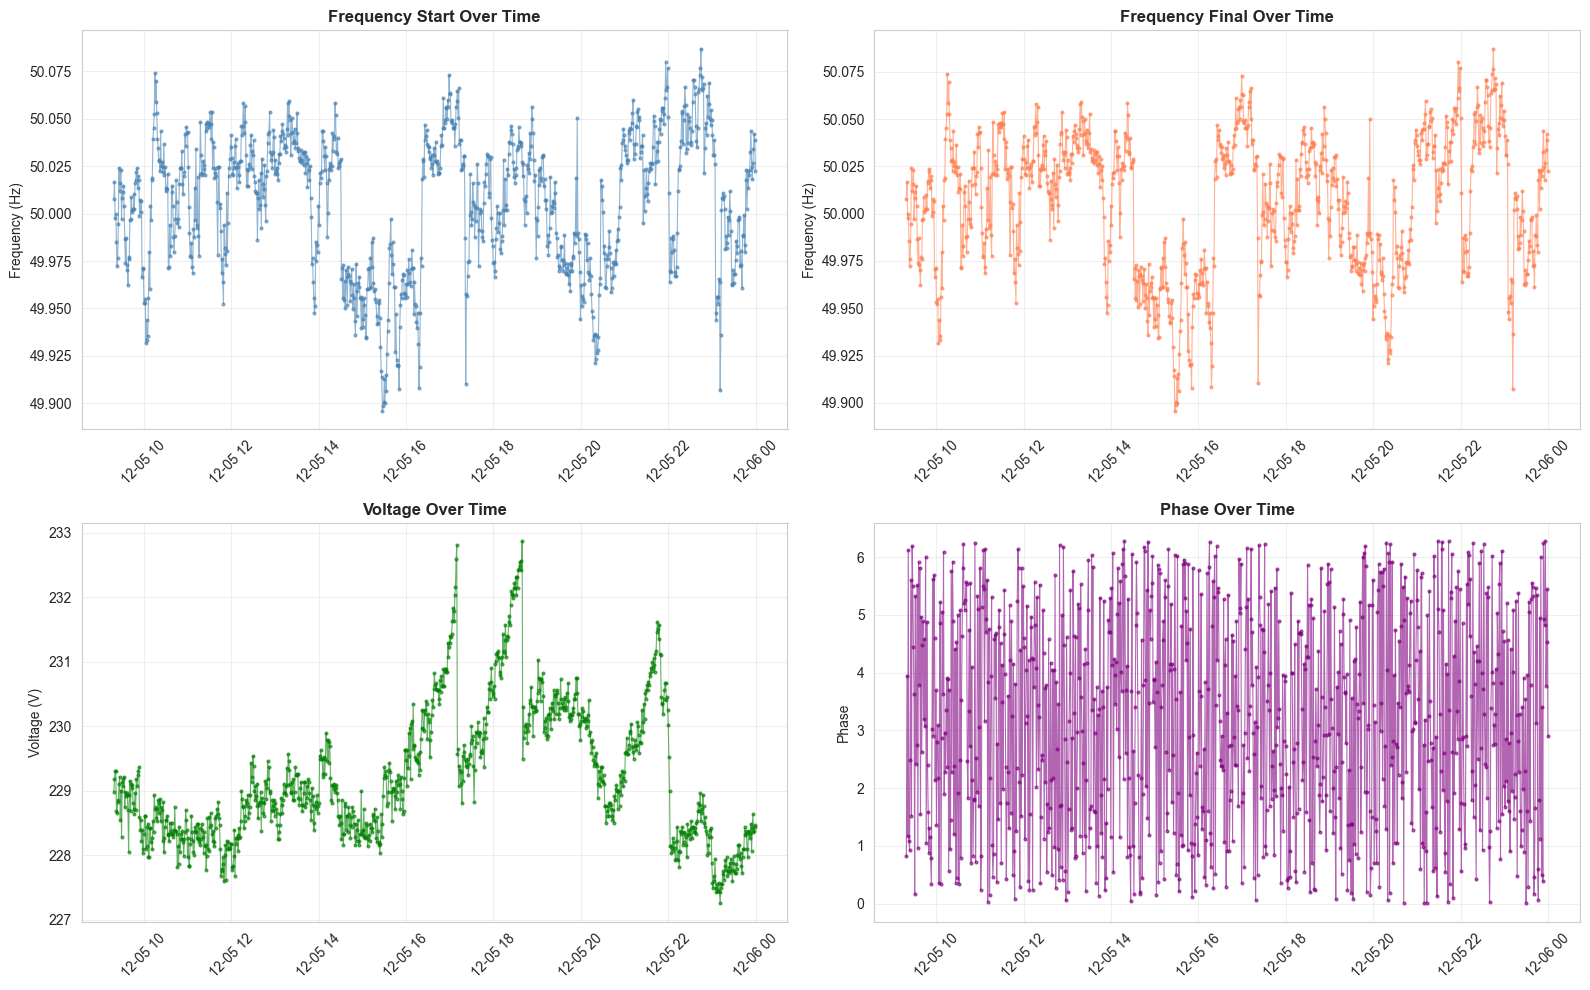

In [107]:
# Time series plots
print("=" * 60)
print("TIME SERIES ANALYSIS")
print("=" * 60)
print(f"Data spans from {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Total duration: {df['timestamp'].max() - df['timestamp'].min()}")
print(f"Records per day: {len(df) / ((df['timestamp'].max() - df['timestamp'].min()).days + 1):.0f}")

# Create time series plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Frequency Start over time (sample every nth point for clarity)
sample_rate = max(1, len(df) // 1000)  # Show ~1000 points
axes[0, 0].plot(df['timestamp'].iloc[::sample_rate], df['freq_start'].iloc[::sample_rate], 
                linewidth=0.8, color='steelblue', marker='o', markersize=2, alpha=0.6)
axes[0, 0].set_title('Frequency Start Over Time', fontweight='bold')
axes[0, 0].set_ylabel('Frequency (Hz)')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Frequency Final over time
axes[0, 1].plot(df['timestamp'].iloc[::sample_rate], df['freq_final'].iloc[::sample_rate], 
                linewidth=0.8, color='coral', marker='o', markersize=2, alpha=0.6)
axes[0, 1].set_title('Frequency Final Over Time', fontweight='bold')
axes[0, 1].set_ylabel('Frequency (Hz)')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Voltage over time
axes[1, 0].plot(df['timestamp'].iloc[::sample_rate], df['voltage'].iloc[::sample_rate], 
                linewidth=0.8, color='green', marker='o', markersize=2, alpha=0.6)
axes[1, 0].set_title('Voltage Over Time', fontweight='bold')
axes[1, 0].set_ylabel('Voltage (V)')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Phase over time
axes[1, 1].plot(df['timestamp'].iloc[::sample_rate], df['phase'].iloc[::sample_rate], 
                linewidth=0.8, color='purple', marker='o', markersize=2, alpha=0.6)
axes[1, 1].set_title('Phase Over Time', fontweight='bold')
axes[1, 1].set_ylabel('Phase')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Frequency Stability & Deviation Analysis

FREQUENCY STABILITY METRICS

FREQUENCY DEVIATION FROM 50 Hz:
  Mean deviation: -0.161067 Hz
  Std deviation: 2.995481 Hz
  Min deviation: -56.218800 Hz
  Max deviation: 3.197400 Hz
  Range: 59.416200 Hz

FREQUENCY CHANGE (Start to Final):
  Mean change: 0.167040 Hz
  Std change: 2.995275 Hz
  Min change: -3.301300 Hz
  Max change: 56.310400 Hz

FREQUENCY CLASSIFICATION (Stable Range: 49.9-50.1 Hz):
  Very Low (<49.9 Hz): 3,094 (0.59%)
  Stable (49.9-50.1 Hz): 524,604 (99.24%)
  Very High (>50.1 Hz): 908 (0.17%)


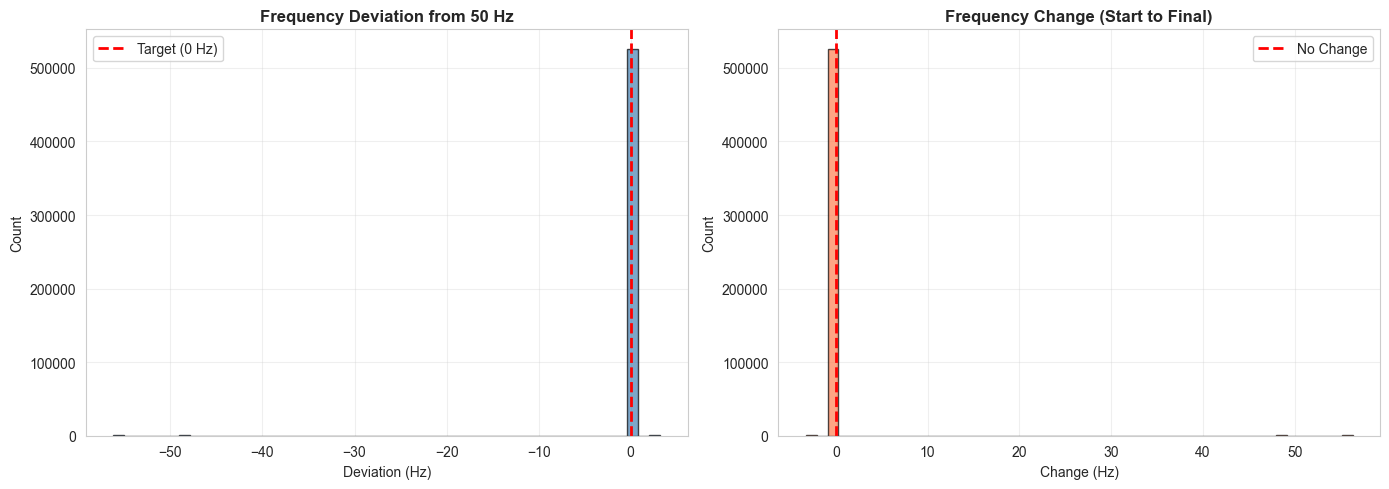

In [108]:
# Calculate frequency deviation and change
df['freq_deviation'] = df['freq_start'] - 50.0  # Assuming nominal frequency is 50 Hz
df['freq_change'] = df['freq_final'] - df['freq_start']

print("=" * 60)
print("FREQUENCY STABILITY METRICS")
print("=" * 60)

print("\nFREQUENCY DEVIATION FROM 50 Hz:")
print(f"  Mean deviation: {df['freq_deviation'].mean():.6f} Hz")
print(f"  Std deviation: {df['freq_deviation'].std():.6f} Hz")
print(f"  Min deviation: {df['freq_deviation'].min():.6f} Hz")
print(f"  Max deviation: {df['freq_deviation'].max():.6f} Hz")
print(f"  Range: {df['freq_deviation'].max() - df['freq_deviation'].min():.6f} Hz")

print("\nFREQUENCY CHANGE (Start to Final):")
print(f"  Mean change: {df['freq_change'].mean():.6f} Hz")
print(f"  Std change: {df['freq_change'].std():.6f} Hz")
print(f"  Min change: {df['freq_change'].min():.6f} Hz")
print(f"  Max change: {df['freq_change'].max():.6f} Hz")

# Classify frequency deviations (Stable: 49.9-50.1 Hz)
low_freq = len(df[df['freq_start'] < 49.9])
stable_freq = len(df[(df['freq_start'] >= 49.9) & (df['freq_start'] <= 50.1)])
high_freq = len(df[df['freq_start'] > 50.1])

print(f"\nFREQUENCY CLASSIFICATION (Stable Range: 49.9-50.1 Hz):")
print(f"  Very Low (<49.9 Hz): {low_freq:,} ({low_freq/len(df)*100:.2f}%)")
print(f"  Stable (49.9-50.1 Hz): {stable_freq:,} ({stable_freq/len(df)*100:.2f}%)")
print(f"  Very High (>50.1 Hz): {high_freq:,} ({high_freq/len(df)*100:.2f}%)")

# Visualize frequency deviation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['freq_deviation'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Target (0 Hz)')
axes[0].set_title('Frequency Deviation from 50 Hz', fontweight='bold')
axes[0].set_xlabel('Deviation (Hz)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(df['freq_change'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
axes[1].set_title('Frequency Change (Start to Final)', fontweight='bold')
axes[1].set_xlabel('Change (Hz)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Unit-Level Analysis

UNIT-LEVEL ANALYSIS

Number of unique units: 1
Unit IDs: [np.int64(1015)]

Records per unit:
unitID
1015    528606
Name: count, dtype: int64

FREQUENCY STATISTICS BY UNIT:
       freq_start                            freq_final                     \
             mean       std     min      max       mean       std      min   
unitID                                                                       
1015    49.838933  2.995481 -6.2188  53.1974  50.005973  0.036117  49.8647   

                   voltage                                 phase            \
            max       mean       std      min      max      mean       std   
unitID                                                                       
1015    50.1026  229.22418  1.049646  226.989  232.976  3.136329  1.802618   

                     
        min     max  
unitID               
1015    0.0  6.2831  


/var/folders/wk/smqrf7z97xvg0rhv6cm0hsn00000gn/T/ipykernel_26338/3131120026.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(unit_freq_data, labels=sorted(unique_units))
/var/folders/wk/smqrf7z97xvg0rhv6cm0hsn00000gn/T/ipykernel_26338/3131120026.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(unit_volt_data, labels=sorted(unique_units))


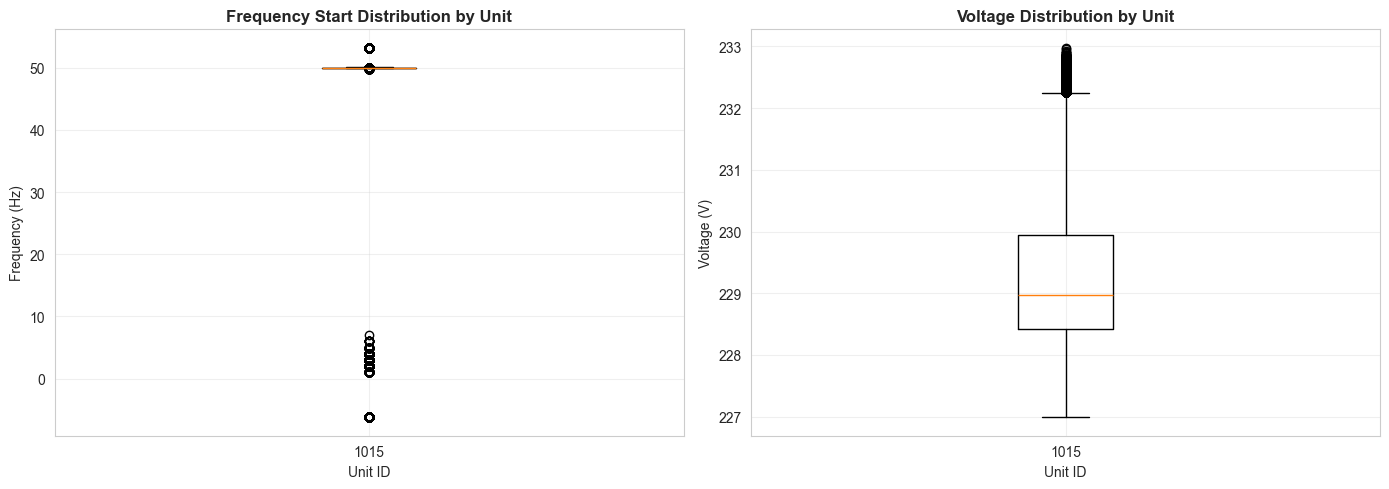

In [109]:
print("=" * 60)
print("UNIT-LEVEL ANALYSIS")
print("=" * 60)

# Unique units
unique_units = df['unitID'].unique()
print(f"\nNumber of unique units: {len(unique_units)}")
print(f"Unit IDs: {sorted(unique_units)}")

# Records per unit
print(f"\nRecords per unit:")
unit_counts = df['unitID'].value_counts().sort_index()
print(unit_counts)

# Statistics per unit
print(f"\nFREQUENCY STATISTICS BY UNIT:")
unit_stats = df.groupby('unitID')[['freq_start', 'freq_final', 'voltage', 'phase']].agg(['mean', 'std', 'min', 'max'])
print(unit_stats)

# Visualize by unit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequency by unit
unit_freq_data = [df[df['unitID'] == uid]['freq_start'].values for uid in sorted(unique_units)]
axes[0].boxplot(unit_freq_data, labels=sorted(unique_units))
axes[0].set_title('Frequency Start Distribution by Unit', fontweight='bold')
axes[0].set_xlabel('Unit ID')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].grid(alpha=0.3)

# Voltage by unit
unit_volt_data = [df[df['unitID'] == uid]['voltage'].values for uid in sorted(unique_units)]
axes[1].boxplot(unit_volt_data, labels=sorted(unique_units))
axes[1].set_title('Voltage Distribution by Unit', fontweight='bold')
axes[1].set_xlabel('Unit ID')
axes[1].set_ylabel('Voltage (V)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Data Patterns & Anomalies

DATA PATTERNS & ANOMALIES

Timestamp duplicates: 50

Large frequency changes (>0.1 Hz): 2643
Sample of large changes:
                  timestamp  freq_start  freq_final  freq_change
12  2014-12-05 09:19:00.100     53.1974     50.0063      -3.1911
13  2014-12-05 09:19:00.200     -6.2188     50.0086      56.2274
14  2014-12-05 09:19:00.300      5.0000     50.0056      45.0056
612 2014-12-05 09:20:00.100     53.1974     49.9747      -3.2227
613 2014-12-05 09:20:00.200     -6.2188     49.9741      56.1929

Voltage anomalies:
  3-sigma anomalies: 3639

Zero/Negative value checks:
  freq_start <= 0: 881
  freq_final <= 0: 0
  voltage <= 0: 0
  phase <= 0: 4

DATA COLLECTION INTERVAL ANALYSIS:
  Mode interval: 0.10 seconds
  Mean interval: 0.10 seconds
  Std interval: 0.00 seconds
  Min interval: 0.00 seconds
  Max interval: 1.10 seconds
  >1 second gaps: 5


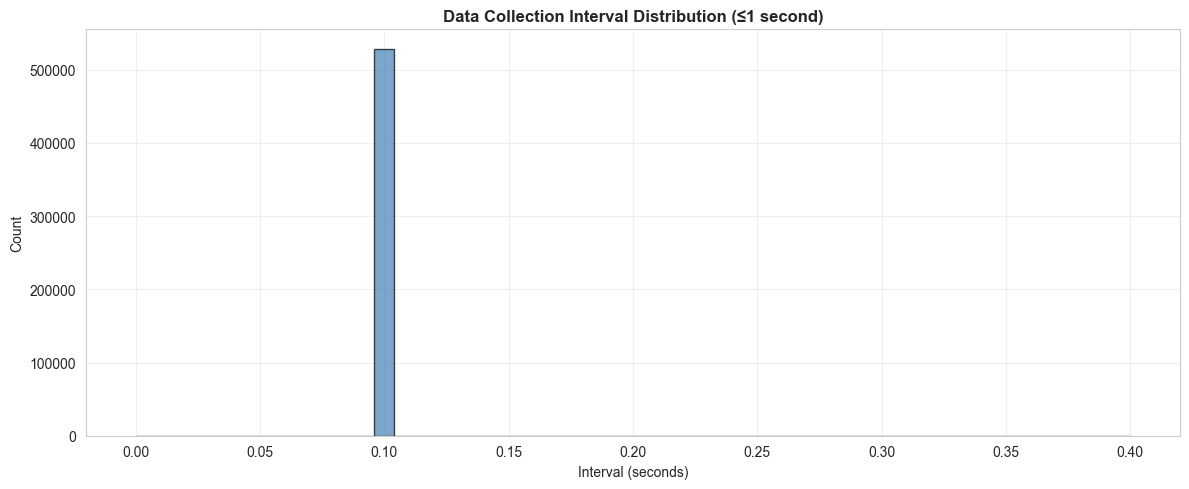


EDA COMPLETE


In [110]:
print("=" * 60)
print("DATA PATTERNS & ANOMALIES")
print("=" * 60)

# Check for duplicate timestamps
print(f"\nTimestamp duplicates: {df['timestamp'].duplicated().sum()}")

# Check for large frequency changes
large_changes = df[abs(df['freq_change']) > 0.1]
print(f"\nLarge frequency changes (>0.1 Hz): {len(large_changes)}")
if len(large_changes) > 0:
    print("Sample of large changes:")
    print(large_changes[['timestamp', 'freq_start', 'freq_final', 'freq_change']].head())

# Voltage anomalies
print(f"\nVoltage anomalies:")
volt_mean = df['voltage'].mean()
volt_std = df['voltage'].std()
volt_anomalies = df[(df['voltage'] < volt_mean - 3*volt_std) | (df['voltage'] > volt_mean + 3*volt_std)]
print(f"  3-sigma anomalies: {len(volt_anomalies)}")

# Zero or negative values check
print(f"\nZero/Negative value checks:")
print(f"  freq_start <= 0: {len(df[df['freq_start'] <= 0])}")
print(f"  freq_final <= 0: {len(df[df['freq_final'] <= 0])}")
print(f"  voltage <= 0: {len(df[df['voltage'] <= 0])}")
print(f"  phase <= 0: {len(df[df['phase'] <= 0])}")

# Time gaps analysis
df_sorted = df.sort_values('timestamp')
time_diffs = df_sorted['timestamp'].diff().dt.total_seconds()
print(f"\nDATA COLLECTION INTERVAL ANALYSIS:")
print(f"  Mode interval: {time_diffs.mode().values[0]:.2f} seconds")
print(f"  Mean interval: {time_diffs.mean():.2f} seconds")
print(f"  Std interval: {time_diffs.std():.2f} seconds")
print(f"  Min interval: {time_diffs.min():.2f} seconds")
print(f"  Max interval: {time_diffs.max():.2f} seconds")
print(f"  >1 second gaps: {len(time_diffs[time_diffs > 1])}")

# Plot time interval distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(time_diffs[time_diffs <= 1], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Data Collection Interval Distribution (≤1 second)', fontweight='bold')
ax.set_xlabel('Interval (seconds)')
ax.set_ylabel('Count')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("EDA COMPLETE")
print("=" * 60)

## 11. Time Series with Anomalies Highlighted

ANOMALIES DETECTED (Frequency stable range: 49.9-50.1 Hz)
Frequency Start anomalies (outside 49.9-50.1 Hz): 4,002
Frequency Final anomalies (outside 49.9-50.1 Hz): 1,368
Voltage anomalies (IQR method): 6,119
Phase anomalies (IQR method): 0


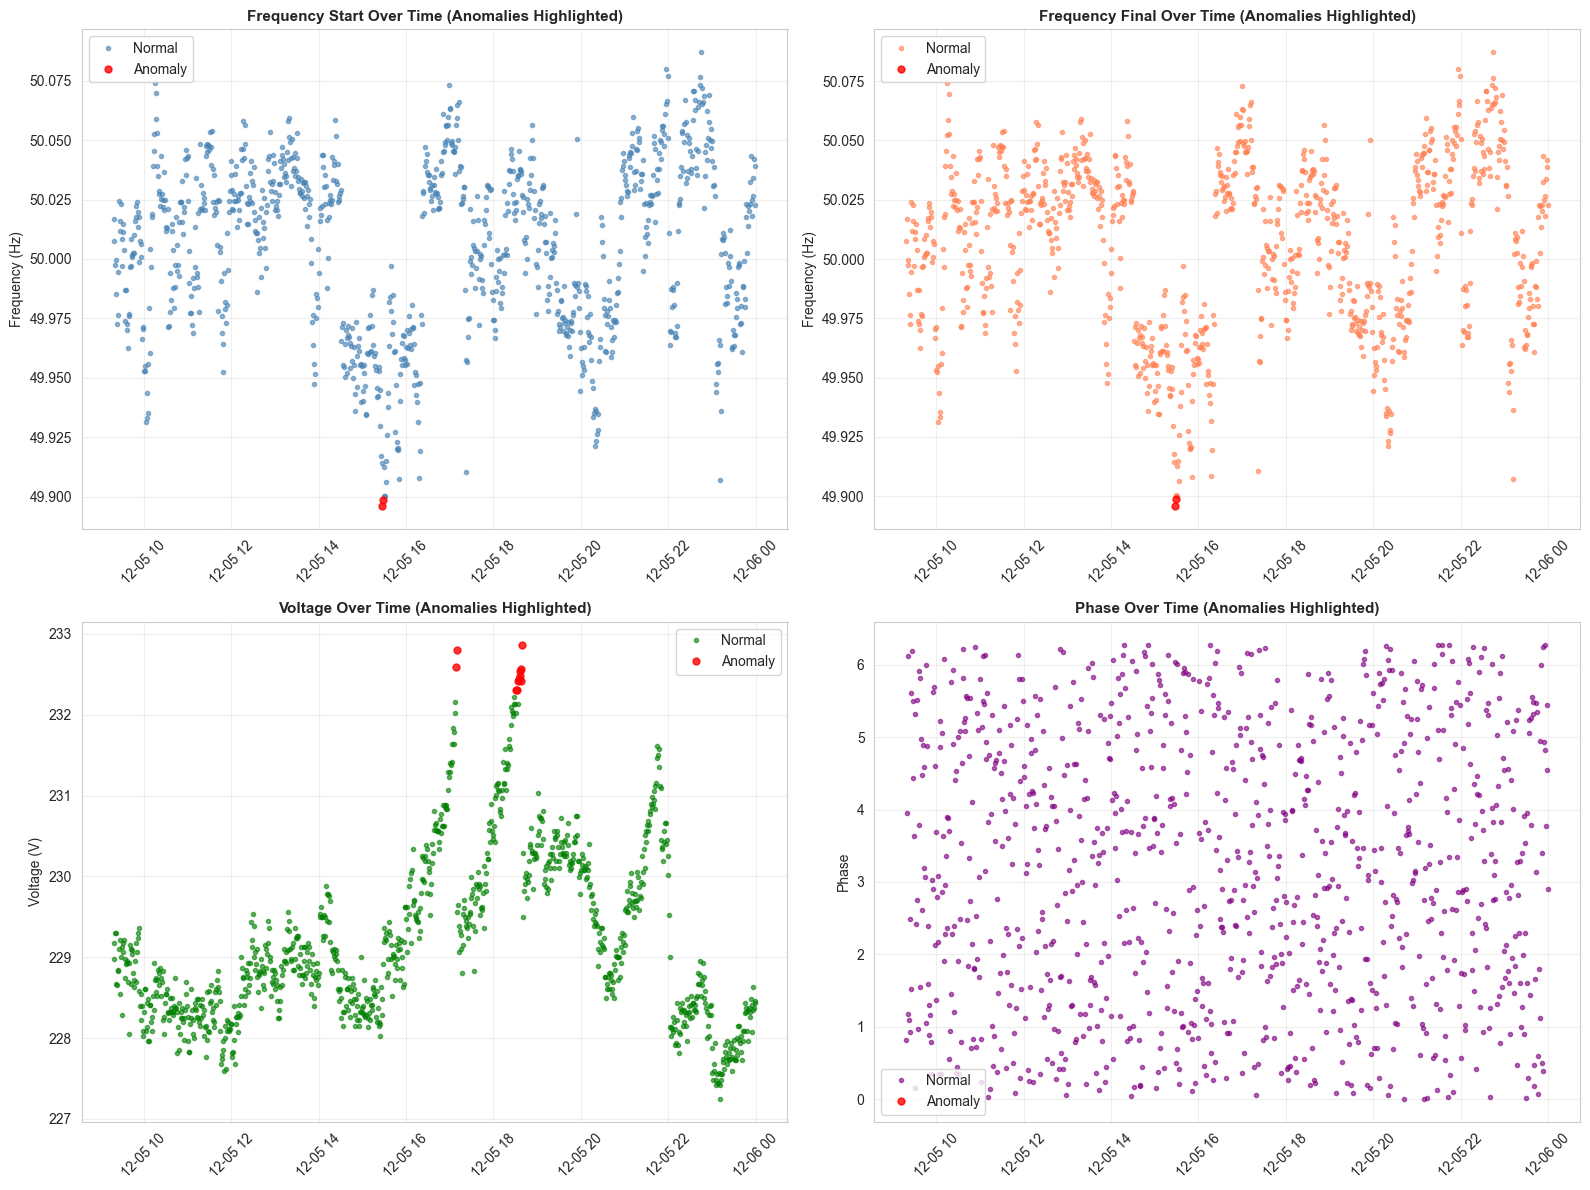

In [111]:
# Detect anomalies using threshold-based method for frequency and IQR for other metrics
def detect_anomalies_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

# Create anomaly flags for each metric
# Frequency anomalies: outside stable range 49.9-50.1 Hz
df['freq_start_anomaly'] = (df['freq_start'] < 49.9) | (df['freq_start'] > 50.1)
df['freq_final_anomaly'] = (df['freq_final'] < 49.9) | (df['freq_final'] > 50.1)
# Voltage and Phase: use IQR method
df['voltage_anomaly'] = detect_anomalies_iqr(df['voltage'])
df['phase_anomaly'] = detect_anomalies_iqr(df['phase'])

print("=" * 60)
print("ANOMALIES DETECTED (Frequency stable range: 49.9-50.1 Hz)")
print("=" * 60)
print(f"Frequency Start anomalies (outside 49.9-50.1 Hz): {df['freq_start_anomaly'].sum():,}")
print(f"Frequency Final anomalies (outside 49.9-50.1 Hz): {df['freq_final_anomaly'].sum():,}")
print(f"Voltage anomalies (IQR method): {df['voltage_anomaly'].sum():,}")
print(f"Phase anomalies (IQR method): {df['phase_anomaly'].sum():,}")

# Create time series plots with anomalies highlighted in red
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sample for visualization
sample_rate = max(1, len(df) // 1000)

# Frequency Start with anomalies
normal_idx = ~df['freq_start_anomaly'].iloc[::sample_rate]
anomaly_idx = df['freq_start_anomaly'].iloc[::sample_rate]

axes[0, 0].plot(df['timestamp'].iloc[::sample_rate][normal_idx], 
                df['freq_start'].iloc[::sample_rate][normal_idx], 
                'o', color='steelblue', markersize=3, alpha=0.6, label='Normal')
axes[0, 0].plot(df['timestamp'].iloc[::sample_rate][anomaly_idx], 
                df['freq_start'].iloc[::sample_rate][anomaly_idx], 
                'o', color='red', markersize=5, alpha=0.8, label='Anomaly')
axes[0, 0].set_title('Frequency Start Over Time (Anomalies Highlighted)', fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('Frequency (Hz)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Frequency Final with anomalies
normal_idx = ~df['freq_final_anomaly'].iloc[::sample_rate]
anomaly_idx = df['freq_final_anomaly'].iloc[::sample_rate]

axes[0, 1].plot(df['timestamp'].iloc[::sample_rate][normal_idx], 
                df['freq_final'].iloc[::sample_rate][normal_idx], 
                'o', color='coral', markersize=3, alpha=0.6, label='Normal')
axes[0, 1].plot(df['timestamp'].iloc[::sample_rate][anomaly_idx], 
                df['freq_final'].iloc[::sample_rate][anomaly_idx], 
                'o', color='red', markersize=5, alpha=0.8, label='Anomaly')
axes[0, 1].set_title('Frequency Final Over Time (Anomalies Highlighted)', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('Frequency (Hz)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Voltage with anomalies
normal_idx = ~df['voltage_anomaly'].iloc[::sample_rate]
anomaly_idx = df['voltage_anomaly'].iloc[::sample_rate]

axes[1, 0].plot(df['timestamp'].iloc[::sample_rate][normal_idx], 
                df['voltage'].iloc[::sample_rate][normal_idx], 
                'o', color='green', markersize=3, alpha=0.6, label='Normal')
axes[1, 0].plot(df['timestamp'].iloc[::sample_rate][anomaly_idx], 
                df['voltage'].iloc[::sample_rate][anomaly_idx], 
                'o', color='red', markersize=5, alpha=0.8, label='Anomaly')
axes[1, 0].set_title('Voltage Over Time (Anomalies Highlighted)', fontweight='bold', fontsize=11)
axes[1, 0].set_ylabel('Voltage (V)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Phase with anomalies
normal_idx = ~df['phase_anomaly'].iloc[::sample_rate]
anomaly_idx = df['phase_anomaly'].iloc[::sample_rate]

axes[1, 1].plot(df['timestamp'].iloc[::sample_rate][normal_idx], 
                df['phase'].iloc[::sample_rate][normal_idx], 
                'o', color='purple', markersize=3, alpha=0.6, label='Normal')
axes[1, 1].plot(df['timestamp'].iloc[::sample_rate][anomaly_idx], 
                df['phase'].iloc[::sample_rate][anomaly_idx], 
                'o', color='red', markersize=5, alpha=0.8, label='Anomaly')
axes[1, 1].set_title('Phase Over Time (Anomalies Highlighted)', fontweight='bold', fontsize=11)
axes[1, 1].set_ylabel('Phase')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

## 12. Anomaly Count by Time Interval

## 13. Zoomed-In Frequency Oscillation Around Anomalies

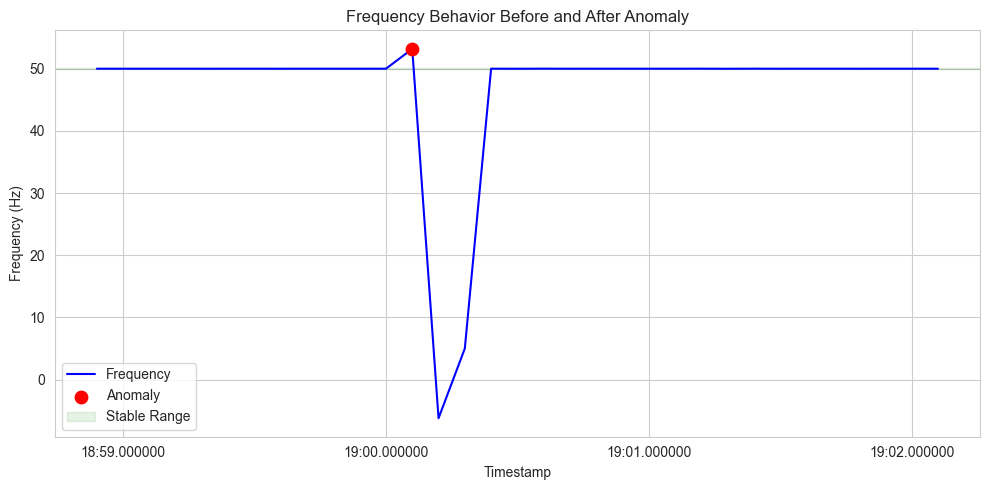

In [116]:
# Choose a single anomaly event and plot frequency before/after
# Find the first anomaly event
anomaly_indices = df[df['freq_start_anomaly']].index

if len(anomaly_indices) > 0:
    anomaly_idx = anomaly_indices[0]
    anomaly_time = df.loc[anomaly_idx, 'timestamp']
    # Select 20 points before and 20 after the anomaly
    before_idx = max(0, anomaly_idx - 20)
    after_idx = min(len(df) - 1, anomaly_idx + 20)
    zoom_df = df.loc[before_idx:after_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(zoom_df['timestamp'], zoom_df['freq_start'], color='blue', label='Frequency')
    plt.scatter(df.loc[anomaly_idx, 'timestamp'], df.loc[anomaly_idx, 'freq_start'], color='red', s=80, label='Anomaly', zorder=5)
    plt.axhspan(49.9, 50.1, color='green', alpha=0.1, label='Stable Range')
    plt.xlabel('Timestamp')
    plt.ylabel('Frequency (Hz)')
    plt.title('Frequency Behavior Before and After Anomaly')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No anomalies detected to zoom in on.')